# 05. Model Comparison

This notebook runs all four tabular baselines under the same split and feature setup:

- Logistic Regression
- Random Forest
- MLP
- XGBoost


In [8]:
from pathlib import Path
import sys

import pandas as pd

sys.path.append(str(Path.cwd()))

from tabular_model_utils import (
    build_tabular_dataset,
    fit_and_evaluate_model,
    plot_comparison_bars,
    plot_evaluation_dashboard,
    set_seed,
)


In [9]:
FEATURE_GROUP = "eth_twitter_combined_features"
ADD_GRAPH_STATS = False
RANDOM_STATE = 42
THRESHOLD_OBJECTIVE = "f1"
MODELS = [
    "logistic_regression",
    "random_forest",
    "mlp",
    "xgboost",
]

set_seed(RANDOM_STATE)


In [10]:
dataset = build_tabular_dataset(
    feature_group=FEATURE_GROUP,
    add_graph_stats=ADD_GRAPH_STATS,
    random_state=RANDOM_STATE,
)
display(dataset["split_df"])
print("Number of input features:", len(dataset["feature_cols"]))


,split,rows,positives,positive_ratio
0,train,7000,788,0.112571
1,val,1500,169,0.112667
2,test,1500,169,0.112667


Number of input features: 24


In [11]:
results = []
fitted = {}

for model_name in MODELS:
    result = fit_and_evaluate_model(
        model_name=model_name,
        dataset=dataset,
        random_state=RANDOM_STATE,
        threshold_objective=THRESHOLD_OBJECTIVE,
    )
    fitted[model_name] = result
    results.append({"model": model_name, **result["metrics"]})

results_df = pd.DataFrame(results).sort_values(["PR-AUC", "F1"], ascending=False)
display(results_df)


,model,Threshold,PR-AUC,ROC-AUC,F1,Precision,Recall,Specificity,NPV,Balanced-Accuracy,...,Brier-Score,Log-Loss,Accuracy,TP,FP,TN,FN,TopK,Precision@K,Recall@K
2,mlp,0.250,0.544345,0.864481,0.544081,0.473684,0.639053,0.909842,0.952044,0.774448,...,0.070154,0.245897,0.879333,108,120,1211,61,169,0.532544,0.532544
3,xgboost,0.650,0.528431,0.860504,0.538462,0.475113,0.621302,0.912847,0.949961,0.767075,...,0.124727,0.398775,0.880000,105,116,1215,64,169,0.538462,0.538462
1,random_forest,0.475,0.502753,0.842600,0.501425,0.483516,0.520710,0.929376,0.938543,0.725043,...,0.090167,0.302144,0.883333,88,94,1237,81,169,0.502959,0.502959
0,logistic_regression,0.700,0.484403,0.865226,0.534704,0.472727,0.615385,0.912847,0.949219,0.764116,...,0.146525,0.478836,0.879333,104,116,1215,65,169,0.544379,0.544379


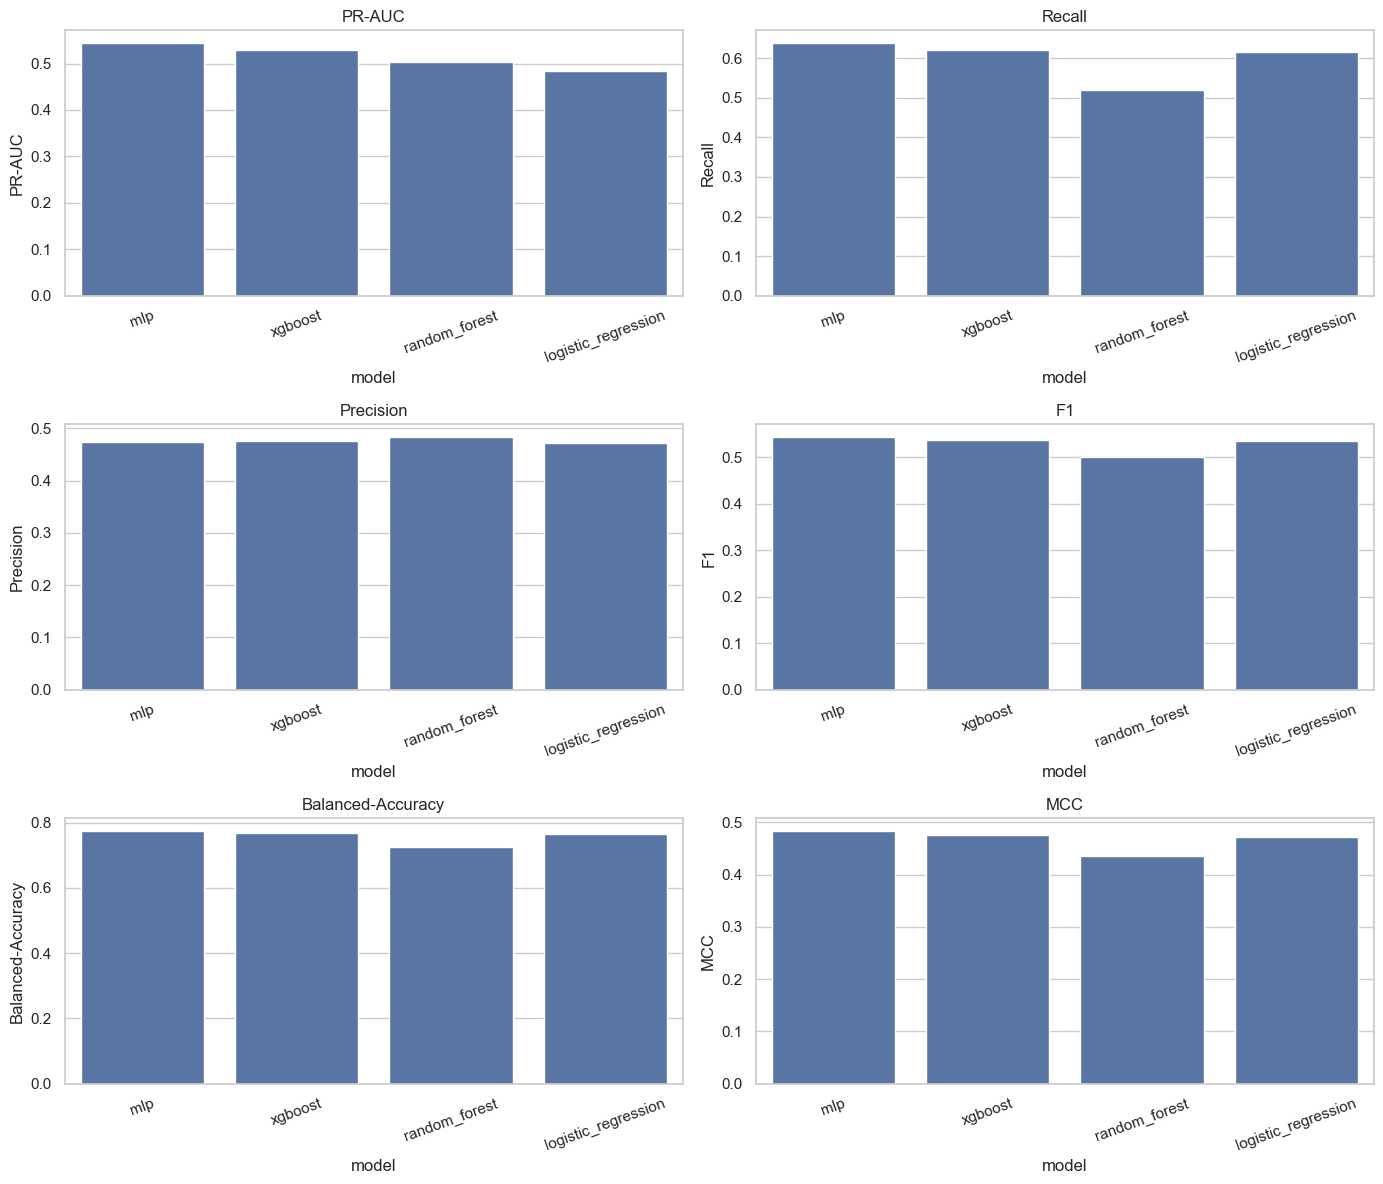

In [12]:
plot_comparison_bars(results_df)


Best model: mlp


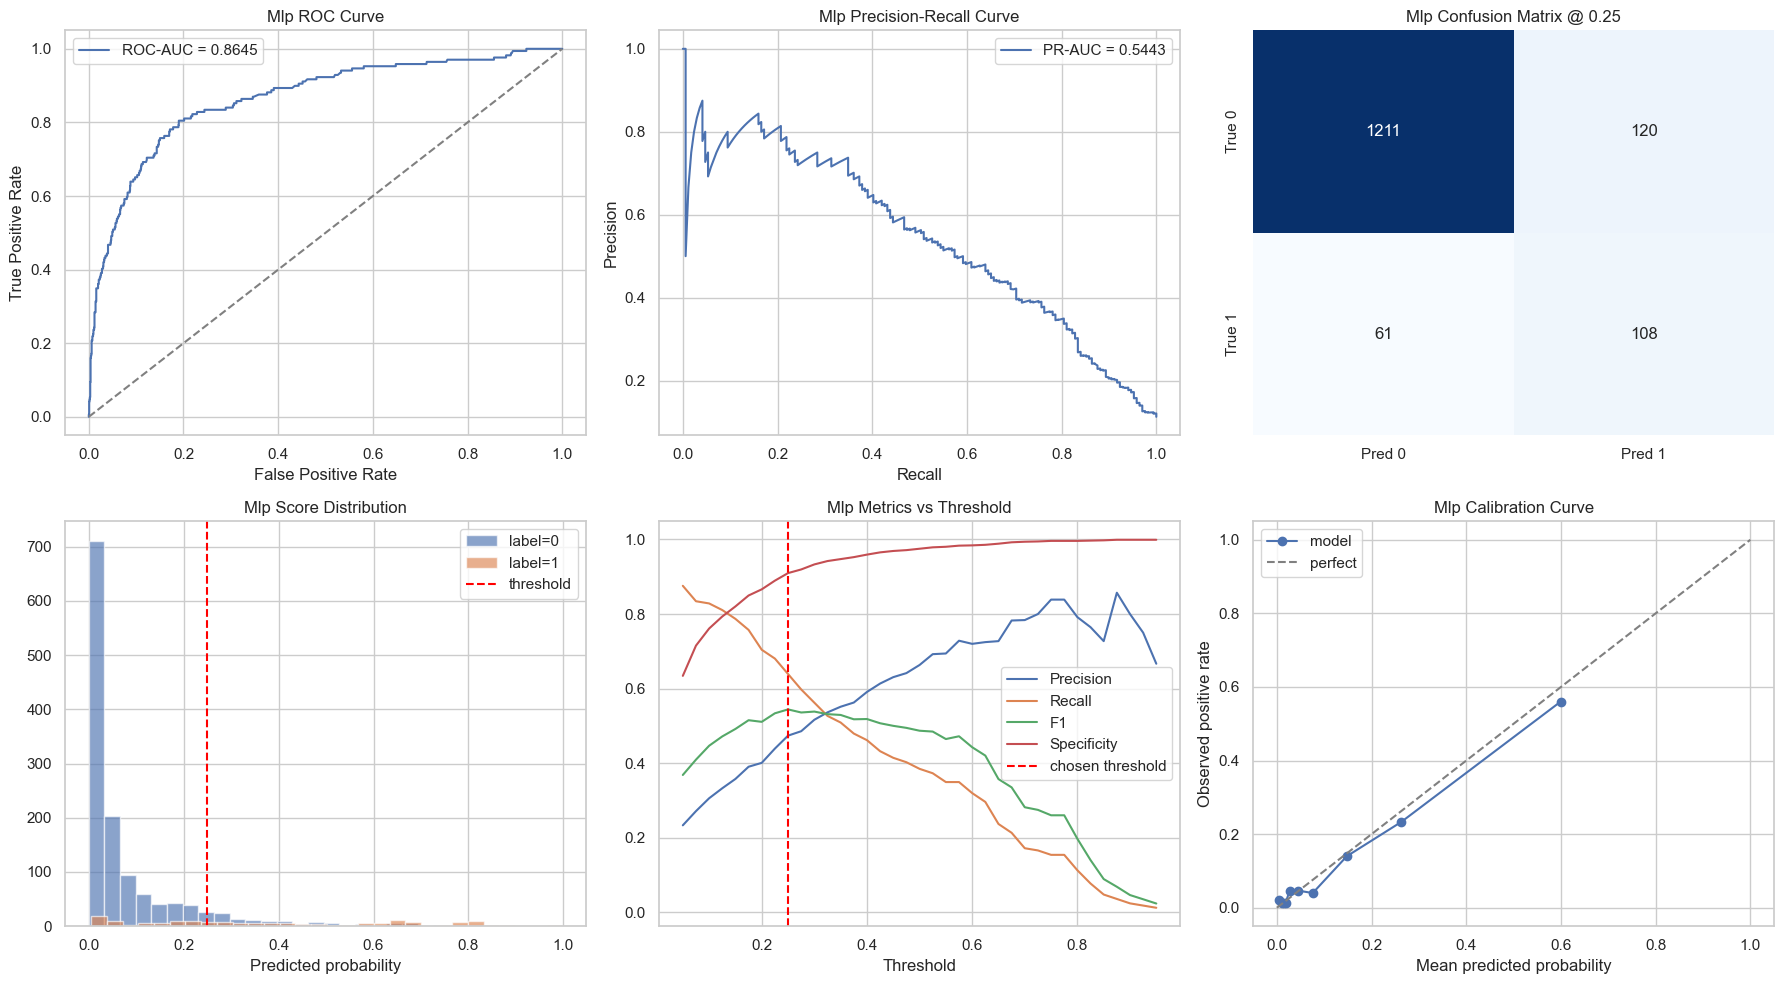

In [13]:
best_model_name = results_df.iloc[0]["model"]
print("Best model:", best_model_name)
best_result = fitted[best_model_name]

plot_evaluation_dashboard(
    y_true=dataset["y_test"].to_numpy(),
    y_prob=best_result["test_prob"],
    threshold=best_result["threshold"],
    title_prefix=best_model_name.replace("_", " ").title(),
)


In [ ]:
comparison_cols = [
    "model",
    "PR-AUC",
    "ROC-AUC",
    "F1",
    "Precision",
    "Recall",
    "Specificity",
    "Balanced-Accuracy",
    "MCC",
    "Brier-Score",
    "Accuracy",
    "Precision@K",
    "Recall@K",
]
results_df[comparison_cols]


,model,PR-AUC,ROC-AUC,F1,Precision,Recall,Specificity,Balanced-Accuracy,MCC,Brier-Score,Accuracy,Precision@K,Recall@K
2,mlp,0.544345,0.864481,0.544081,0.473684,0.639053,0.909842,0.774448,0.483405,0.070154,0.879333,0.532544,0.532544
3,xgboost,0.528431,0.860504,0.538462,0.475113,0.621302,0.912847,0.767075,0.476501,0.124727,0.880000,0.538462,0.538462
1,random_forest,0.502753,0.842600,0.501425,0.483516,0.520710,0.929376,0.725043,0.435848,0.090167,0.883333,0.502959,0.502959
0,logistic_regression,0.484403,0.865226,0.534704,0.472727,0.615385,0.912847,0.764116,0.472107,0.146525,0.879333,0.544379,0.544379


: 

## Notes

This notebook is the main leaderboard for the non-graph baselines.
It defaults to a stricter feature-only setup by keeping `ADD_GRAPH_STATS = False`.
Keep the graph-model comparisons separate from this table unless the split protocol and input features are aligned.
